In [2]:
# Mount Drive and import libraries
from google.colab import drive
drive.mount('/content/drive')

import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
import matplotlib.pyplot as plt

PROJECT_PATH = '/content/drive/MyDrive/Brain-Tumor-Classification'
processed_path = f'{PROJECT_PATH}/data/processed'

Mounted at /content/drive


In [3]:
# Load transfer learning data (RGB, 224x224)
X_train = np.load(f'{processed_path}/X_train_transfer.npy')
X_val = np.load(f'{processed_path}/X_val_transfer.npy')
X_test = np.load(f'{processed_path}/X_test_transfer.npy')

y_train = np.load(f'{processed_path}/y_train_transfer.npy')
y_val = np.load(f'{processed_path}/y_val_transfer.npy')
y_test = np.load(f'{processed_path}/y_test_transfer.npy')

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Train: (4760, 224, 224, 3) (4760, 4)
Val: (840, 224, 224, 3) (840, 4)
Test: (1600, 224, 224, 3) (1600, 4)


In [4]:
# Rescale data back to 0-255 for EfficientNet
X_train = (X_train * 255.0).astype('float32')
X_val = (X_val * 255.0).astype('float32')
X_test = (X_test * 255.0).astype('float32')

print("Pixel value range after rescaling:")
print(f"Min: {X_train.min()}, Max: {X_train.max()}")

Pixel value range after rescaling:
Min: 0.0, Max: 255.0


In [4]:
# Load EfficientNetB0 pretrained base (without top classification layers)
base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all base model layers
base_model.trainable = False

print(f"Total layers in base model: {len(base_model.layers)}")
print(f"Trainable params after freezing: {sum([tf.size(w).numpy() for w in base_model.trainable_weights])}")

Total layers in base model: 238
Trainable params after freezing: 0


In [5]:
# Build full model with new classification head
inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(4, activation='softmax')(x)

model_transfer = tf.keras.Model(inputs, outputs)
model_transfer.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,214,055 (16.08 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [6]:
# Compile model - Phase 1 (frozen base)
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [7]:
# Callbacks for Phase 1
checkpoint_path_phase1 = f'{PROJECT_PATH}/models/transfer_best_phase1.keras'

checkpoint_phase1 = ModelCheckpoint(
    filepath=checkpoint_path_phase1,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stopping_phase1 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [8]:
# Train Phase 1 - frozen base
print("Phase 1: Training with frozen base...")

history_phase1 = model_transfer.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=[checkpoint_phase1, early_stopping_phase1]
)

Phase 1: Training with frozen base...
Epoch 1/20
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.7326 - loss: 0.6812
Epoch 1: val_accuracy improved from None to 0.86667, saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/transfer_best_phase1.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/transfer_best_phase1.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 79s 315ms/step - accuracy: 0.8158 - loss: 0.4888 - val_accuracy: 0.8667 - val_loss: 0.3351
Epoch 2/20
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.8834 - loss: 0.3183
Epoch 2: val_accuracy improved from 0.86667 to 0.90238, saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/transfer_best_phase1.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/transfer_best_phase1.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.8870 - loss: 0.3016 - val_accuracy: 0.9024 - val_loss: 0.2684
Ep

In [4]:
model_transfer = tf.keras.models.load_model(
    f'{PROJECT_PATH}/models/transfer_best_phase1.keras'
)

In [5]:
base_model = model_transfer.layers[1]
print(base_model.name)

efficientnetb0


In [6]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

In [7]:
trainable_count = sum(layer.trainable for layer in base_model.layers)

print("Trainable layers:", trainable_count)

Trainable layers: 20


In [8]:
model_transfer.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [9]:
checkpoint_path_phase2 = f'{PROJECT_PATH}/models/transfer_best_phase2.keras'

checkpoint_phase2 = ModelCheckpoint(
    filepath=checkpoint_path_phase2,
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stopping_phase2 = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [10]:
history_phase2 = model_transfer.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[
        checkpoint_phase2,
        early_stopping_phase2
    ]
)

Epoch 1/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.8505 - loss: 0.5095
Epoch 1: val_accuracy improved from None to 0.92381, saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/transfer_best_phase2.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/transfer_best_phase2.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 87s 338ms/step - accuracy: 0.8716 - loss: 0.3989 - val_accuracy: 0.9238 - val_loss: 0.1872
Epoch 2/10
148/149 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - accuracy: 0.9183 - loss: 0.2334
Epoch 2: val_accuracy improved from 0.92381 to 0.92857, saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/transfer_best_phase2.keras

Epoch 2: finished saving model to /content/drive/MyDrive/Brain-Tumor-Classification/models/transfer_best_phase2.keras
149/149 ━━━━━━━━━━━━━━━━━━━━ 8s 54ms/step - accuracy: 0.9137 - loss: 0.2379 - val_accuracy: 0.9286 - val_loss: 0.1911
Epoch 3/10
149/149 ━━━━━━━━━━━━━━━━━━━━ 

In [5]:
# Load best model from Phase 2
model_transfer = tf.keras.models.load_model(
    f'{PROJECT_PATH}/models/transfer_best_phase2.keras'
)

50/50 ━━━━━━━━━━━━━━━━━━━━ 21s 38ms/step - accuracy: 0.9181 - loss: 0.4085
Transfer Learning Test Accuracy: 0.9181
Transfer Learning Test Loss: 0.4085
50/50 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step


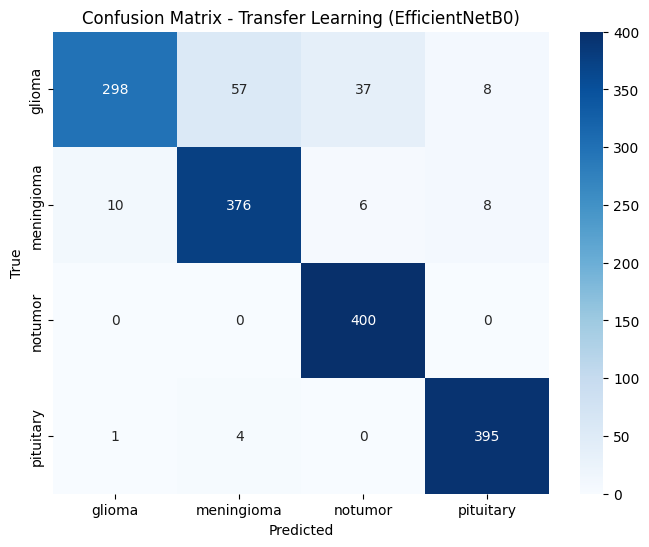

              precision    recall  f1-score   support

      glioma       0.96      0.74      0.84       400
  meningioma       0.86      0.94      0.90       400
     notumor       0.90      1.00      0.95       400
   pituitary       0.96      0.99      0.97       400

    accuracy                           0.92      1600
   macro avg       0.92      0.92      0.92      1600
weighted avg       0.92      0.92      0.92      1600



In [7]:
# Final evaluation on test set
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

test_loss, test_accuracy = model_transfer.evaluate(X_test, y_test)

print(f"Transfer Learning Test Accuracy: {test_accuracy:.4f}")
print(f"Transfer Learning Test Loss: {test_loss:.4f}")

y_pred_probs = model_transfer.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - Transfer Learning (EfficientNetB0)')
plt.savefig(f'{PROJECT_PATH}/results/figures/transfer_confusion_matrix.png', dpi=150)
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

In [8]:
# Save transfer learning results
import json

report_dict = classification_report(
    y_true, y_pred,
    target_names=class_names,
    output_dict=True
)

with open(f'{PROJECT_PATH}/results/transfer_classification_report.json', 'w') as f:
    json.dump(report_dict, f, indent=4)

transfer_summary = {
    'model': 'EfficientNetB0 Transfer Learning',
    'phase1_epochs': 20,
    'phase2_epochs': 10,
    'best_val_accuracy_phase1': 0.9536,
    'best_val_accuracy_phase2': 0.9560,
    'test_accuracy': 0.9181,
    'test_loss': 0.4085
}

with open(f'{PROJECT_PATH}/results/transfer_summary.json', 'w') as f:
    json.dump(transfer_summary, f, indent=4)

print("Transfer learning results saved.")

Transfer learning results saved.


In [9]:
# Save final comparison table
comparison = {
    'CNN_from_Scratch': {
        'test_accuracy': 0.7681,
        'macro_f1': 0.75,
        'glioma_recall': 0.62,
        'meningioma_recall': 0.49,
        'notumor_recall': 1.00,
        'pituitary_recall': 0.96,
        'total_params': 454660
    },
    'EfficientNetB0_Transfer': {
        'test_accuracy': 0.9181,
        'macro_f1': 0.92,
        'glioma_recall': 0.74,
        'meningioma_recall': 0.94,
        'notumor_recall': 1.00,
        'pituitary_recall': 0.99,
        'total_params': 4214055
    }
}

with open(f'{PROJECT_PATH}/results/models_comparison.json', 'w') as f:
    json.dump(comparison, f, indent=4)

print("Comparison table saved.")

Comparison table saved.
